In [212]:
# ============================================================
# WEEK 10 - CUSTOMER CHURN PREDICTION
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [213]:
# ============================================================
# CELL 2: CREATE OUTPUT DIRECTORIES
# ============================================================

directories = [
    "outputs/charts",
    "outputs/processed_data",
    "outputs/results",
    "reports"
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("✅ Output directories ready.")

✅ Output directories ready.


In [214]:
# ============================================================
# CELL 3: LOAD CUSTOMER CHURN DATA
# ============================================================

DATA_PATH = "data/customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("CUSTOMER CHURN DATASET LOADED")
print("=" * 70)

print("Dataset shape:", df.shape)

display(df.head())

CUSTOMER CHURN DATASET LOADED
Dataset shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [215]:
# ============================================================
# CELL 4: DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")

df.info()

DATASET INFORMATION

Columns:
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']

Data types:
CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
SeniorCitizen       int64
Churn               int64
dtype: object

Dataset shape:
(500, 9)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non

In [216]:
# ============================================================
# CELL 5: STATISTICAL SUMMARY
# ============================================================

print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(
    df.describe(include="all").T
)

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,500,500,C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,500.0,NaN,NaN,NaN,36.532,20.667057,1.0,19.0,37.0,54.0,71.0
MonthlyCharges,500.0,NaN,NaN,NaN,113.636,51.799903,20.0,67.0,115.0,158.0,199.0
TotalCharges,500.0,NaN,NaN,NaN,4237.882,2260.619837,159.0,2237.25,4182.5,6266.75,7992.0
Contract,500,3,One year,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,500,3,Credit Card,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,500,2,No,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,500.0,NaN,NaN,NaN,0.498,0.500497,0.0,0.0,0.0,1.0,1.0
Churn,500.0,NaN,NaN,NaN,0.106,0.308146,0.0,0.0,0.0,0.0,1.0


In [217]:
# ============================================================
# CELL 6: MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

display(missing_report)

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

MISSING VALUE ANALYSIS


,Missing_Count,Missing_Percentage
CustomerID,0,0.0
Tenure,0,0.0
MonthlyCharges,0,0.0
TotalCharges,0,0.0
Contract,0,0.0
PaymentMethod,0,0.0
PaperlessBilling,0,0.0
SeniorCitizen,0,0.0
Churn,0,0.0



Total missing values: 0


In [218]:
# ============================================================
# CELL 7: DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

print("Duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("✅ No duplicate rows found.")
else:
    print("⚠️ Duplicate rows found.")

DUPLICATE ANALYSIS
Duplicate rows: 0
✅ No duplicate rows found.


In [219]:
# ============================================================
# CELL 8: FEATURE TYPE ANALYSIS
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

FEATURE TYPES

Numerical columns:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']

Categorical columns:
['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling']


In [220]:
# ============================================================
# CELL 9: IDENTIFY TARGET COLUMN
# ============================================================

possible_target_columns = [
    "Churn",
    "churn",
    "Exited",
    "Exited_Customer",
    "Churn_Status"
]

target_column = None

for column in possible_target_columns:
    if column in df.columns:
        target_column = column
        break

if target_column is None:
    print("⚠️ Churn target column was not automatically detected.")
    print("Available columns:")
    print(df.columns.tolist())
else:
    print("=" * 70)
    print("TARGET VARIABLE")
    print("=" * 70)

    print("Target column:", target_column)

    print("\nTarget values:")
    print(df[target_column].value_counts(dropna=False))

TARGET VARIABLE
Target column: Churn

Target values:
Churn
0    447
1     53
Name: count, dtype: int64


CUSTOMER CHURN DISTRIBUTION


Churn
0    447
1     53
Name: count, dtype: int64


Churn percentages:


Churn
0    89.4
1    10.6
Name: count, dtype: float64

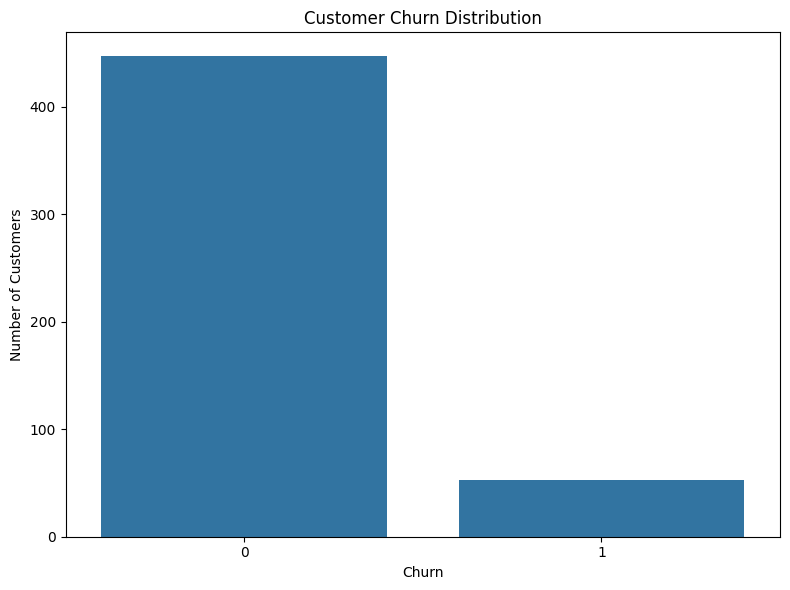

In [221]:
# ============================================================
# CELL 10: CHURN DISTRIBUTION
# ============================================================

if target_column is not None:

    churn_counts = df[target_column].value_counts()

    print("=" * 70)
    print("CUSTOMER CHURN DISTRIBUTION")
    print("=" * 70)

    display(churn_counts)

    print("\nChurn percentages:")

    display(
        (churn_counts / len(df) * 100).round(2)
    )

    plt.figure(figsize=(8, 6))

    sns.countplot(
        data=df,
        x=target_column
    )

    plt.title("Customer Churn Distribution")
    plt.xlabel("Churn")
    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.savefig(
        "outputs/charts/churn_distribution.png",
        dpi=300
    )

    plt.show()

else:

    print(
        "❌ Target column not found. "
        "Please check Cell 9 output."
    )

In [222]:
# ============================================================
# CELL 11: SEPARATE TARGET AND FEATURES
# ============================================================

if target_column is None:
    raise ValueError(
        "Target column was not detected. "
        "Check Cell 9."
    )

X_raw = df.drop(
    columns=[target_column]
).copy()

y_raw = df[target_column].copy()

print("=" * 70)
print("FEATURE AND TARGET SEPARATION")
print("=" * 70)

print("Target column:", target_column)
print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

print("\nFeatures:")
print(X_raw.columns.tolist())

FEATURE AND TARGET SEPARATION
Target column: Churn
Feature shape: (500, 8)
Target shape: (500,)

Features:
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']


In [223]:
# ============================================================
# CELL 12: LABEL ENCODING
# ============================================================

label_encoded_df = X_raw.copy()

label_encoders = {}

label_columns = label_encoded_df.select_dtypes(
    include="object"
).columns.tolist()

for column in label_columns:

    encoder = LabelEncoder()

    label_encoded_df[column] = encoder.fit_transform(
        label_encoded_df[column].astype(str)
    )

    label_encoders[column] = encoder

print("=" * 70)
print("LABEL ENCODING")
print("=" * 70)

print("Encoded columns:")
print(label_columns)

display(
    label_encoded_df.head()
)

LABEL ENCODING
Encoded columns:
['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling']


C:\Users\revim\AppData\Local\Temp\ipykernel_6188\635498946.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  label_columns = label_encoded_df.select_dtypes(


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen
0,0,6,64,1540,1,1,0,1
1,1,21,113,1753,0,2,1,1
2,2,27,31,1455,2,1,0,1
3,3,53,29,7150,0,2,0,1
4,4,16,185,1023,1,2,0,1


In [224]:
# ============================================================
# CELL 13: LABEL ENCODING MAPPINGS
# ============================================================

print("=" * 70)
print("LABEL ENCODING MAPPINGS")
print("=" * 70)

label_mappings = {}

for column, encoder in label_encoders.items():

    mapping = {
        category: int(index)
        for index, category in enumerate(
            encoder.classes_
        )
    }

    label_mappings[column] = mapping

    print(f"\n{column}:")
    
    for category, value in mapping.items():
        print(f"  {category} -> {value}")

LABEL ENCODING MAPPINGS

CustomerID:
  C00001 -> 0
  C00002 -> 1
  C00003 -> 2
  C00004 -> 3
  C00005 -> 4
  C00006 -> 5
  C00007 -> 6
  C00008 -> 7
  C00009 -> 8
  C00010 -> 9
  C00011 -> 10
  C00012 -> 11
  C00013 -> 12
  C00014 -> 13
  C00015 -> 14
  C00016 -> 15
  C00017 -> 16
  C00018 -> 17
  C00019 -> 18
  C00020 -> 19
  C00021 -> 20
  C00022 -> 21
  C00023 -> 22
  C00024 -> 23
  C00025 -> 24
  C00026 -> 25
  C00027 -> 26
  C00028 -> 27
  C00029 -> 28
  C00030 -> 29
  C00031 -> 30
  C00032 -> 31
  C00033 -> 32
  C00034 -> 33
  C00035 -> 34
  C00036 -> 35
  C00037 -> 36
  C00038 -> 37
  C00039 -> 38
  C00040 -> 39
  C00041 -> 40
  C00042 -> 41
  C00043 -> 42
  C00044 -> 43
  C00045 -> 44
  C00046 -> 45
  C00047 -> 46
  C00048 -> 47
  C00049 -> 48
  C00050 -> 49
  C00051 -> 50
  C00052 -> 51
  C00053 -> 52
  C00054 -> 53
  C00055 -> 54
  C00056 -> 55
  C00057 -> 56
  C00058 -> 57
  C00059 -> 58
  C00060 -> 59
  C00061 -> 60
  C00062 -> 61
  C00063 -> 62
  C00064 -> 63
  C00065 -> 6

In [225]:
# ============================================================
# CELL 14: ONE-HOT ENCODING
# ============================================================

one_hot_columns = X_raw.select_dtypes(
    include="object"
).columns.tolist()

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

if len(one_hot_columns) > 0:

    encoded_array = one_hot_encoder.fit_transform(
        X_raw[one_hot_columns].astype(str)
    )

    encoded_feature_names = (
        one_hot_encoder
        .get_feature_names_out(one_hot_columns)
    )

    one_hot_df = pd.DataFrame(
        encoded_array,
        columns=encoded_feature_names,
        index=X_raw.index
    )

    one_hot_encoded_df = pd.concat(
        [
            X_raw.drop(columns=one_hot_columns),
            one_hot_df
        ],
        axis=1
    )

else:

    one_hot_encoded_df = X_raw.copy()

print("=" * 70)
print("ONE-HOT ENCODING")
print("=" * 70)

print(
    "Original shape:",
    X_raw.shape
)

print(
    "Encoded shape:",
    one_hot_encoded_df.shape
)

display(
    one_hot_encoded_df.head()
)

ONE-HOT ENCODING
Original shape: (500, 8)
Encoded shape: (500, 512)


C:\Users\revim\AppData\Local\Temp\ipykernel_6188\2328603973.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  one_hot_columns = X_raw.select_dtypes(


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,CustomerID_C00001,CustomerID_C00002,CustomerID_C00003,CustomerID_C00004,CustomerID_C00005,CustomerID_C00006,...,CustomerID_C00499,CustomerID_C00500,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes
0,6,64,1540,1,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,21,113,1753,1,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,27,31,1455,1,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,53,29,7150,1,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,16,185,1023,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [226]:
# ============================================================
# CELL 15: ORDINAL ENCODING
# ============================================================

ordinal_columns = X_raw.select_dtypes(
    include="object"
).columns.tolist()

if len(ordinal_columns) > 0:

    ordinal_column = ordinal_columns[0]

    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    ordinal_encoded_values = ordinal_encoder.fit_transform(
        X_raw[[ordinal_column]].astype(str)
    )

    ordinal_df = X_raw.copy()

    ordinal_df[
        ordinal_column + "_Ordinal"
    ] = ordinal_encoded_values.astype(int)

    print("=" * 70)
    print("ORDINAL ENCODING")
    print("=" * 70)

    print(
        "Demonstration column:",
        ordinal_column
    )

    display(
        ordinal_df[
            [ordinal_column,
            ordinal_column + "_Ordinal"]
        ].head(10)
    )

else:

    ordinal_column = None

    print(
        "No categorical column available "
        "for ordinal encoding."
    )

ORDINAL ENCODING
Demonstration column: CustomerID


C:\Users\revim\AppData\Local\Temp\ipykernel_6188\1655334390.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ordinal_columns = X_raw.select_dtypes(


,CustomerID,CustomerID_Ordinal
0,C00001,0
1,C00002,1
2,C00003,2
3,C00004,3
4,C00005,4
5,C00006,5
6,C00007,6
7,C00008,7
8,C00009,8
9,C00010,9


In [227]:
# ============================================================
# CELL 16: COMPARE ENCODING METHODS
# ============================================================

print("=" * 70)
print("ENCODING METHODS COMPARISON")
print("=" * 70)

print(
    f"Original feature count: "
    f"{X_raw.shape[1]}"
)

print(
    f"Label encoded feature count: "
    f"{label_encoded_df.shape[1]}"
)

print(
    f"One-hot encoded feature count: "
    f"{one_hot_encoded_df.shape[1]}"
)

if ordinal_column is not None:

    print(
        f"Ordinal encoding demonstration: "
        f"{ordinal_column}"
    )

print("\nEncoding methods implemented:")

print("✅ Label Encoding")
print("✅ One-Hot Encoding")
print("✅ Ordinal Encoding")

ENCODING METHODS COMPARISON
Original feature count: 8
Label encoded feature count: 8
One-hot encoded feature count: 512
Ordinal encoding demonstration: CustomerID

Encoding methods implemented:
✅ Label Encoding
✅ One-Hot Encoding
✅ Ordinal Encoding


In [228]:
# ============================================================
# CELL 17: SAVE ENCODING RESULTS
# ============================================================

label_encoded_df.to_csv(
    "outputs/processed_data/label_encoded_data.csv",
    index=False
)

one_hot_encoded_df.to_csv(
    "outputs/processed_data/one_hot_encoded_data.csv",
    index=False
)

if ordinal_column is not None:

    ordinal_df.to_csv(
        "outputs/processed_data/ordinal_encoded_data.csv",
        index=False
    )

print("=" * 70)
print("ENCODING OUTPUTS SAVED")
print("=" * 70)

print(
    "✅ Label encoding:"
    " outputs/processed_data/label_encoded_data.csv"
)

print(
    "✅ One-hot encoding:"
    " outputs/processed_data/one_hot_encoded_data.csv"
)

if ordinal_column is not None:

    print(
        "✅ Ordinal encoding:"
        " outputs/processed_data/ordinal_encoded_data.csv"
    )

ENCODING OUTPUTS SAVED
✅ Label encoding: outputs/processed_data/label_encoded_data.csv
✅ One-hot encoding: outputs/processed_data/one_hot_encoded_data.csv
✅ Ordinal encoding: outputs/processed_data/ordinal_encoded_data.csv


In [229]:
# ============================================================
# CELL 18: CATEGORICAL CARDINALITY
# ============================================================

categorical_summary = []

for column in X_raw.select_dtypes(
    include="object"
).columns:

    categorical_summary.append({
        "Column": column,
        "Unique_Values": X_raw[column].nunique(),
        "Missing_Values": X_raw[column].isnull().sum()
    })

categorical_summary_df = pd.DataFrame(
    categorical_summary
)

print("=" * 70)
print("CATEGORICAL FEATURE SUMMARY")
print("=" * 70)

if len(categorical_summary_df) > 0:

    display(categorical_summary_df)

else:

    print(
        "No categorical columns detected."
    )

CATEGORICAL FEATURE SUMMARY


C:\Users\revim\AppData\Local\Temp\ipykernel_6188\2008028628.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in X_raw.select_dtypes(


,Column,Unique_Values,Missing_Values
0,CustomerID,500,0
1,Contract,3,0
2,PaymentMethod,3,0
3,PaperlessBilling,2,0


In [230]:
# ============================================================
# CELL 19: ENCODING DOCUMENTATION
# ============================================================

encoding_documentation = pd.DataFrame({
    "Method": [
        "Label Encoding",
        "One-Hot Encoding",
        "Ordinal Encoding"
    ],
    "Purpose": [
        "Convert categories into integer labels",
        "Create binary columns for categories",
        "Encode categories using ordered numerical values"
    ],
    "Used_In_Project": [
        "Demonstration",
        "Main categorical preprocessing",
        "Demonstration"
    ]
})

display(
    encoding_documentation
)

encoding_documentation.to_csv(
    "outputs/results/encoding_methods.csv",
    index=False
)

print(
    "✅ Encoding documentation saved."
)

,Method,Purpose,Used_In_Project
0,Label Encoding,Convert categories into integer labels,Demonstration
1,One-Hot Encoding,Create binary columns for categories,Main categorical preprocessing
2,Ordinal Encoding,Encode categories using ordered numerical values,Demonstration


✅ Encoding documentation saved.


In [231]:
# ============================================================
# CELL 20: ENCODING VERIFICATION
# ============================================================

print("=" * 70)
print("WEEK 10 - ENCODING VERIFICATION")
print("=" * 70)

checks = {
    "Label Encoding": len(label_encoded_df) == len(X_raw),
    "One-Hot Encoding": len(one_hot_encoded_df) == len(X_raw),
    "Ordinal Encoding": (
        ordinal_column is not None
        and len(ordinal_df) == len(X_raw)
    ),
    "Encoding Documentation": os.path.exists(
        "outputs/results/encoding_methods.csv"
    )
}

for name, status in checks.items():

    print(
        f"{'✅' if status else '❌'} {name}"
    )

print("\n🎯 Three encoding methods demonstrated.")

WEEK 10 - ENCODING VERIFICATION
✅ Label Encoding
✅ One-Hot Encoding
✅ Ordinal Encoding
✅ Encoding Documentation

🎯 Three encoding methods demonstrated.


In [232]:
# ============================================================
# CELL 21: NUMERICAL FEATURE PREPARATION
# ============================================================

numeric_features = X_raw.select_dtypes(
    include=np.number
).columns.tolist()

print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)

print(numeric_features)

print(
    "\nNumber of numerical features:",
    len(numeric_features)
)

NUMERICAL FEATURES
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

Number of numerical features: 4


In [233]:
# ============================================================
# CELL 22: STANDARD SCALING
# ============================================================

standard_scaler = StandardScaler()

if len(numeric_features) > 0:

    standard_scaled_array = standard_scaler.fit_transform(
        X_raw[numeric_features]
    )

    standard_scaled_df = pd.DataFrame(
        standard_scaled_array,
        columns=[
            column + "_StandardScaled"
            for column in numeric_features
        ],
        index=X_raw.index
    )

    print("=" * 70)
    print("STANDARD SCALING")
    print("=" * 70)

    display(
        standard_scaled_df.head()
    )

else:

    standard_scaled_df = pd.DataFrame(
        index=X_raw.index
    )

    print(
        "No numerical features available."
    )

STANDARD SCALING


,Tenure_StandardScaled,MonthlyCharges_StandardScaled,TotalCharges_StandardScaled,SeniorCitizen_StandardScaled
0,-1.478807,-0.959185,-1.194621,1.004008
1,-0.752287,-0.012290,-1.100305,1.004008
2,-0.461679,-1.596890,-1.232259,1.004008
3,0.797622,-1.635539,1.289485,1.004008
4,-0.994460,1.379066,-1.423548,1.004008


In [234]:
# ============================================================
# CELL 23: STANDARD SCALING VERIFICATION
# ============================================================

if len(standard_scaled_df.columns) > 0:

    standard_statistics = pd.DataFrame({
        "Feature": standard_scaled_df.columns,
        "Mean": standard_scaled_df.mean().values,
        "Std_Deviation": standard_scaled_df.std(
            ddof=0
        ).values
    })

    print("=" * 70)
    print("STANDARD SCALING STATISTICS")
    print("=" * 70)

    display(
        standard_statistics.round(4)
    )

STANDARD SCALING STATISTICS


,Feature,Mean,Std_Deviation
0,Tenure_StandardScaled,0.0,1.0
1,MonthlyCharges_StandardScaled,0.0,1.0
2,TotalCharges_StandardScaled,0.0,1.0
3,SeniorCitizen_StandardScaled,-0.0,1.0


In [235]:
# ============================================================
# CELL 24: MIN-MAX SCALING
# ============================================================

minmax_scaler = MinMaxScaler()

if len(numeric_features) > 0:

    minmax_scaled_array = minmax_scaler.fit_transform(
        X_raw[numeric_features]
    )

    minmax_scaled_df = pd.DataFrame(
        minmax_scaled_array,
        columns=[
            column + "_MinMaxScaled"
            for column in numeric_features
        ],
        index=X_raw.index
    )

    print("=" * 70)
    print("MIN-MAX SCALING")
    print("=" * 70)

    display(
        minmax_scaled_df.head()
    )

else:

    minmax_scaled_df = pd.DataFrame(
        index=X_raw.index
    )

MIN-MAX SCALING


,Tenure_MinMaxScaled,MonthlyCharges_MinMaxScaled,TotalCharges_MinMaxScaled,SeniorCitizen_MinMaxScaled
0,0.071429,0.245810,0.176305,1.0
1,0.285714,0.519553,0.203498,1.0
2,0.371429,0.061453,0.165454,1.0
3,0.742857,0.050279,0.892506,1.0
4,0.214286,0.921788,0.110303,1.0


In [236]:
# ============================================================
# CELL 25: MIN-MAX SCALING VERIFICATION
# ============================================================

if len(minmax_scaled_df.columns) > 0:

    minmax_statistics = pd.DataFrame({
        "Feature": minmax_scaled_df.columns,
        "Minimum": minmax_scaled_df.min().values,
        "Maximum": minmax_scaled_df.max().values
    })

    print("=" * 70)
    print("MIN-MAX SCALING STATISTICS")
    print("=" * 70)

    display(
        minmax_statistics.round(4)
    )

MIN-MAX SCALING STATISTICS


,Feature,Minimum,Maximum
0,Tenure_MinMaxScaled,0.0,1.0
1,MonthlyCharges_MinMaxScaled,0.0,1.0
2,TotalCharges_MinMaxScaled,0.0,1.0
3,SeniorCitizen_MinMaxScaled,0.0,1.0


In [237]:
# ============================================================
# CELL 26: SCALING COMPARISON
# ============================================================

print("=" * 70)
print("STANDARD SCALING VS MIN-MAX SCALING")
print("=" * 70)

if len(numeric_features) > 0:

    comparison_feature = numeric_features[0]

    comparison_df = pd.DataFrame({
        "Original": X_raw[comparison_feature],
        "Standard_Scaled": standard_scaled_df[
            comparison_feature + "_StandardScaled"
        ],
        "MinMax_Scaled": minmax_scaled_df[
            comparison_feature + "_MinMaxScaled"
        ]
    })

    display(
        comparison_df.head(10)
    )

    print(
        f"\nComparison feature: {comparison_feature}"
    )

STANDARD SCALING VS MIN-MAX SCALING


,Original,Standard_Scaled,MinMax_Scaled
0,6,-1.478807,0.071429
1,21,-0.752287,0.285714
2,27,-0.461679,0.371429
3,53,0.797622,0.742857
4,16,-0.994460,0.214286
5,55,0.894491,0.771429
6,66,1.427272,0.928571
7,61,1.185099,0.857143
8,64,1.330403,0.900000
9,14,-1.091329,0.185714



Comparison feature: Tenure


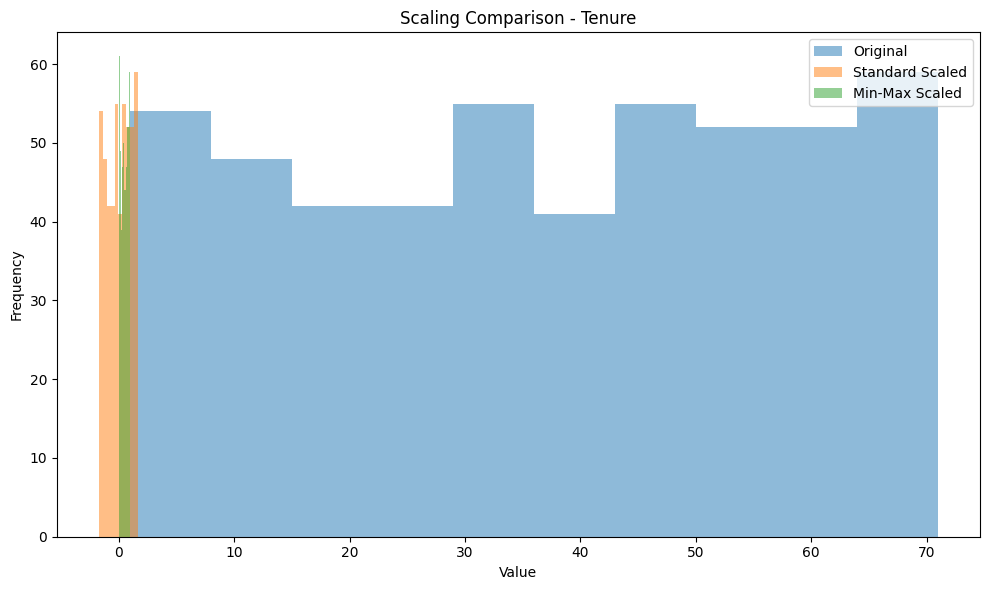

In [238]:
# ============================================================
# CELL 27: SCALING VISUALIZATION
# ============================================================

if len(numeric_features) > 0:

    comparison_feature = numeric_features[0]

    plt.figure(figsize=(10, 6))

    plt.hist(
        X_raw[comparison_feature],
        alpha=0.5,
        label="Original"
    )

    plt.hist(
        standard_scaled_df[
            comparison_feature + "_StandardScaled"
        ],
        alpha=0.5,
        label="Standard Scaled"
    )

    plt.hist(
        minmax_scaled_df[
            comparison_feature + "_MinMaxScaled"
        ],
        alpha=0.5,
        label="Min-Max Scaled"
    )

    plt.title(
        f"Scaling Comparison - {comparison_feature}"
    )

    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        "outputs/charts/scaling_comparison.png",
        dpi=300
    )

    plt.show()

In [239]:
# ============================================================
# CELL 28: IQR OUTLIER DETECTION
# ============================================================

iqr_results = []

for column in numeric_features:

    Q1 = X_raw[column].quantile(0.25)
    Q3 = X_raw[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (X_raw[column] < lower_bound) |
        (X_raw[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    iqr_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage":
            round(
                outlier_count / len(X_raw) * 100,
                2
            )
    })

iqr_results_df = pd.DataFrame(
    iqr_results
)

print("=" * 70)
print("IQR OUTLIER DETECTION")
print("=" * 70)

display(
    iqr_results_df.round(3)
)

IQR OUTLIER DETECTION


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Tenure,19.00,54.00,35.0,-33.5,106.5,0,0.0
1,MonthlyCharges,67.00,158.00,91.0,-69.5,294.5,0,0.0
2,TotalCharges,2237.25,6266.75,4029.5,-3807.0,12311.0,0,0.0
3,SeniorCitizen,0.00,1.00,1.0,-1.5,2.5,0,0.0


In [240]:
# ============================================================
# CELL 29: Z-SCORE OUTLIER DETECTION
# ============================================================

zscore_results = []

for column in numeric_features:

    values = X_raw[column].dropna()

    z_scores = np.abs(
        stats.zscore(values)
    )

    outlier_count = (
        z_scores > 3
    ).sum()

    zscore_results.append({
        "Feature": column,
        "Mean": values.mean(),
        "Std_Deviation": values.std(),
        "ZScore_Threshold": 3,
        "Outlier_Count": int(outlier_count),
        "Outlier_Percentage":
            round(
                outlier_count / len(values) * 100,
                2
            )
    })

zscore_results_df = pd.DataFrame(
    zscore_results
)

print("=" * 70)
print("Z-SCORE OUTLIER DETECTION")
print("=" * 70)

display(
    zscore_results_df.round(3)
)

Z-SCORE OUTLIER DETECTION


,Feature,Mean,Std_Deviation,ZScore_Threshold,Outlier_Count,Outlier_Percentage
0,Tenure,36.532,20.667,3,0,0.0
1,MonthlyCharges,113.636,51.800,3,0,0.0
2,TotalCharges,4237.882,2260.620,3,0,0.0
3,SeniorCitizen,0.498,0.500,3,0,0.0


In [241]:
# ============================================================
# CELL 30: SAVE PREPROCESSING RESULTS
# ============================================================

if len(standard_scaled_df.columns) > 0:

    standard_scaled_df.to_csv(
        "outputs/processed_data/standard_scaled_data.csv",
        index=False
    )

if len(minmax_scaled_df.columns) > 0:

    minmax_scaled_df.to_csv(
        "outputs/processed_data/minmax_scaled_data.csv",
        index=False
    )

iqr_results_df.to_csv(
    "outputs/results/iqr_outlier_results.csv",
    index=False
)

zscore_results_df.to_csv(
    "outputs/results/zscore_outlier_results.csv",
    index=False
)

print("=" * 70)
print("PREPROCESSING RESULTS SAVED")
print("=" * 70)

print("✅ Standard scaled data")
print("✅ Min-Max scaled data")
print("✅ IQR outlier results")
print("✅ Z-score outlier results")

PREPROCESSING RESULTS SAVED
✅ Standard scaled data
✅ Min-Max scaled data
✅ IQR outlier results
✅ Z-score outlier results


In [242]:
# ============================================================
# CELL 31: INSPECT FEATURES FOR FEATURE ENGINEERING
# ============================================================

print("=" * 70)
print("AVAILABLE FEATURES")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column} | dtype: {df[column].dtype}")

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(
    X_raw.select_dtypes(
        include="object"
    ).columns.tolist()
)

AVAILABLE FEATURES
1. CustomerID | dtype: str
2. Tenure | dtype: int64
3. MonthlyCharges | dtype: int64
4. TotalCharges | dtype: int64
5. Contract | dtype: str
6. PaymentMethod | dtype: str
7. PaperlessBilling | dtype: str
8. SeniorCitizen | dtype: int64
9. Churn | dtype: int64

Numerical features:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

Categorical features:
['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling']


C:\Users\revim\AppData\Local\Temp\ipykernel_6188\3667203469.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_raw.select_dtypes(


In [243]:
# ============================================================
# CELL 32: CREATE FEATURE ENGINEERING DATASET
# ============================================================

feature_df = df.copy()

print("=" * 70)
print("FEATURE ENGINEERING DATASET")
print("=" * 70)

print("Original shape:", feature_df.shape)

display(feature_df.head())

FEATURE ENGINEERING DATASET
Original shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [244]:
# ============================================================
# CELL 33: CUSTOMER LIFETIME VALUE
# ============================================================

created_features = []

monthly_col = next(
    (
        col for col in feature_df.columns
        if col.lower().replace("_", "") in [
            "monthlycharges",
            "monthlycharge"
        ]
    ),
    None
)

tenure_col = next(
    (
        col for col in feature_df.columns
        if col.lower() == "tenure"
    ),
    None
)

if monthly_col and tenure_col:

    feature_df["Customer_Lifetime_Value"] = (
        pd.to_numeric(
            feature_df[monthly_col],
            errors="coerce"
        )
        *
        pd.to_numeric(
            feature_df[tenure_col],
            errors="coerce"
        )
    )

    created_features.append(
        "Customer_Lifetime_Value"
    )

    print(
        "✅ Created Customer_Lifetime_Value"
    )

else:

    print(
        "⚠️ MonthlyCharges and/or tenure "
        "not available."
    )

✅ Created Customer_Lifetime_Value


In [245]:
# ============================================================
# CELL 34: AVERAGE MONTHLY VALUE
# ============================================================

if monthly_col:

    feature_df["Average_Monthly_Value"] = (
        pd.to_numeric(
            feature_df[monthly_col],
            errors="coerce"
        )
    )

    created_features.append(
        "Average_Monthly_Value"
    )

    print(
        "✅ Created Average_Monthly_Value"
    )

else:

    print(
        "⚠️ Monthly charge column unavailable."
    )

✅ Created Average_Monthly_Value


In [246]:
# ============================================================
# CELL 35: TENURE GROUP
# ============================================================

if tenure_col:

    tenure_values = pd.to_numeric(
        feature_df[tenure_col],
        errors="coerce"
    )

    feature_df["Tenure_Group"] = pd.cut(
        tenure_values,
        bins=[
            -np.inf,
            12,
            24,
            48,
            np.inf
        ],
        labels=[
            "New",
            "Developing",
            "Established",
            "Loyal"
        ]
    )

    created_features.append(
        "Tenure_Group"
    )

    print(
        "✅ Created Tenure_Group"
    )

else:

    print(
        "⚠️ Tenure column unavailable."
    )

✅ Created Tenure_Group


In [247]:
# ============================================================
# CELL 36: CHARGE PER TENURE MONTH
# ============================================================

if monthly_col and tenure_col:

    monthly_values = pd.to_numeric(
        feature_df[monthly_col],
        errors="coerce"
    )

    tenure_values = pd.to_numeric(
        feature_df[tenure_col],
        errors="coerce"
    )

    feature_df["Charge_Per_Tenure_Month"] = (
        monthly_values /
        tenure_values.replace(0, np.nan)
    )

    created_features.append(
        "Charge_Per_Tenure_Month"
    )

    print(
        "✅ Created Charge_Per_Tenure_Month"
    )

else:

    print(
        "⚠️ Required columns unavailable."
    )

✅ Created Charge_Per_Tenure_Month


In [248]:
# ============================================================
# CELL 37: TOTAL CHARGES PER TENURE
# ============================================================

total_charges_col = next(
    (
        col for col in feature_df.columns
        if col.lower().replace("_", "") in [
            "totalcharges",
            "totalcharge"
        ]
    ),
    None
)

if total_charges_col and tenure_col:

    total_values = pd.to_numeric(
        feature_df[total_charges_col],
        errors="coerce"
    )

    tenure_values = pd.to_numeric(
        feature_df[tenure_col],
        errors="coerce"
    )

    feature_df["Total_Charges_Per_Month"] = (
        total_values /
        tenure_values.replace(0, np.nan)
    )

    created_features.append(
        "Total_Charges_Per_Month"
    )

    print(
        "✅ Created Total_Charges_Per_Month"
    )

else:

    print(
        "⚠️ TotalCharges and/or tenure unavailable."
    )

✅ Created Total_Charges_Per_Month


In [249]:
# ============================================================
# CELL 38: PAYMENT EFFICIENCY
# ============================================================

payment_col = next(
    (
        col for col in feature_df.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "payment",
                "charges",
                "charge"
            ]
        )
        and pd.api.types.is_numeric_dtype(
            feature_df[col]
        )
    ),
    None
)

if payment_col and monthly_col:

    payment_values = pd.to_numeric(
        feature_df[payment_col],
        errors="coerce"
    )

    monthly_values = pd.to_numeric(
        feature_df[monthly_col],
        errors="coerce"
    )

    if payment_col != monthly_col:

        feature_df["Payment_Efficiency"] = (
            payment_values /
            monthly_values.replace(0, np.nan)
        )

        created_features.append(
            "Payment_Efficiency"
        )

        print(
            "✅ Created Payment_Efficiency"
        )

    else:

        print(
            "⚠️ Suitable separate payment column "
            "was not found."
        )

else:

    print(
        "⚠️ Suitable payment-related columns "
        "were not available."
    )

⚠️ Suitable separate payment column was not found.


In [250]:
# ============================================================
# CELL 39: FEATURE ENGINEERING SUMMARY
# ============================================================

print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(
    "Original feature count:",
    len(df.columns)
)

print(
    "New features created:",
    len(created_features)
)

print("\nCreated features:")

for feature in created_features:
    print("✅", feature)

print(
    "\nFinal feature count:",
    len(feature_df.columns)
)

display(
    feature_df.head()
)

FEATURE ENGINEERING SUMMARY
Original feature count: 9
New features created: 5

Created features:
✅ Customer_Lifetime_Value
✅ Average_Monthly_Value
✅ Tenure_Group
✅ Charge_Per_Tenure_Month
✅ Total_Charges_Per_Month

Final feature count: 14


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Customer_Lifetime_Value,Average_Monthly_Value,Tenure_Group,Charge_Per_Tenure_Month,Total_Charges_Per_Month
0,C00001,6,64,1540,One year,Credit Card,No,1,0,384,64,New,10.666667,256.666667
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,2373,113,Developing,5.380952,83.476190
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,837,31,Established,1.148148,53.888889
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,1537,29,Loyal,0.547170,134.905660
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,2960,185,Developing,11.562500,63.937500


In [251]:
# ============================================================
# CELL 40: SAVE ENGINEERED DATASET
# ============================================================

feature_df.to_csv(
    "outputs/processed_data/engineered_customer_churn.csv",
    index=False
)

feature_documentation = pd.DataFrame({
    "Feature": created_features,
    "Description": [
        {
            "Customer_Lifetime_Value":
                "Monthly charges multiplied by customer tenure.",
            "Average_Monthly_Value":
                "Monthly charge associated with the customer.",
            "Tenure_Group":
                "Customer grouped into New, Developing, Established, or Loyal.",
            "Charge_Per_Tenure_Month":
                "Monthly charge divided by customer tenure.",
            "Total_Charges_Per_Month":
                "Total charges divided by customer tenure.",
            "Payment_Efficiency":
                "Payment-related numerical value relative to monthly charges."
        }.get(
            feature,
            "Engineered business feature."
        )
        for feature in created_features
    ]
})

feature_documentation.to_csv(
    "outputs/results/feature_engineering_summary.csv",
    index=False
)

print("=" * 70)
print("FEATURE ENGINEERING OUTPUTS")
print("=" * 70)

print(
    "✅ Engineered dataset saved:"
)
print(
    "outputs/processed_data/engineered_customer_churn.csv"
)

print(
    "\n✅ Feature documentation saved:"
)
print(
    "outputs/results/feature_engineering_summary.csv"
)

FEATURE ENGINEERING OUTPUTS
✅ Engineered dataset saved:
outputs/processed_data/engineered_customer_churn.csv

✅ Feature documentation saved:
outputs/results/feature_engineering_summary.csv


In [252]:
# ============================================================
# CELL 41: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

ml_df = feature_df.copy()

# Remove target from features
X_ml = ml_df.drop(
    columns=[target_column]
).copy()

y_ml = ml_df[target_column].copy()

print("=" * 70)
print("ML DATASET PREPARATION")
print("=" * 70)

print("Feature shape:", X_ml.shape)
print("Target shape:", y_ml.shape)

print("\nTarget distribution:")
print(y_ml.value_counts(dropna=False))

ML DATASET PREPARATION
Feature shape: (500, 13)
Target shape: (500,)

Target distribution:
Churn
0    447
1     53
Name: count, dtype: int64


In [253]:
# ============================================================
# CELL 42: PREPARE BINARY TARGET
# ============================================================

y_clean = y_ml.copy()

unique_targets = y_clean.dropna().unique()

print("Original target values:")
print(unique_targets)

if len(unique_targets) == 2:

    # If already numeric 0/1
    if set(unique_targets).issubset({0, 1}):

        y_encoded = y_clean.astype(int)

    else:

        target_encoder = LabelEncoder()

        y_encoded = pd.Series(
            target_encoder.fit_transform(
                y_clean.astype(str)
            ),
            index=y_clean.index,
            name=target_column
        )

        print("\nTarget encoding:")
        for value, encoded in zip(
            target_encoder.classes_,
            range(len(target_encoder.classes_))
        ):
            print(f"{value} -> {encoded}")

else:

    raise ValueError(
        "Expected exactly 2 target classes "
        "for binary churn prediction."
    )

print("\nEncoded target distribution:")
print(y_encoded.value_counts())

Original target values:
[0 1]

Encoded target distribution:
Churn
0    447
1     53
Name: count, dtype: int64


In [254]:
# ============================================================
# CELL 43: FINAL FEATURE TYPES
# ============================================================

numeric_features_ml = X_ml.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_ml = X_ml.select_dtypes(
    exclude=np.number
).columns.tolist()

print("=" * 70)
print("FINAL ML FEATURE TYPES")
print("=" * 70)

print("\nNumerical features:")
for feature in numeric_features_ml:
    print("•", feature)

print("\nCategorical features:")
for feature in categorical_features_ml:
    print("•", feature)

print(
    "\nTotal numerical features:",
    len(numeric_features_ml)
)

print(
    "Total categorical features:",
    len(categorical_features_ml)
)

FINAL ML FEATURE TYPES

Numerical features:
• Tenure
• MonthlyCharges
• TotalCharges
• SeniorCitizen
• Customer_Lifetime_Value
• Average_Monthly_Value
• Charge_Per_Tenure_Month
• Total_Charges_Per_Month

Categorical features:
• CustomerID
• Contract
• PaymentMethod
• PaperlessBilling
• Tenure_Group

Total numerical features: 8
Total categorical features: 5


In [255]:
# ============================================================
# CELL 44: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print(
    "\nTraining churn distribution:"
)

print(
    y_train.value_counts(normalize=True).round(3)
)

TRAIN-TEST SPLIT
Training features: (400, 13)
Testing features: (100, 13)
Training target: (400,)
Testing target: (100,)

Training churn distribution:
Churn
0    0.895
1    0.105
Name: proportion, dtype: float64


In [256]:
# ============================================================
# CELL 45: BUILD PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features_ml
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features_ml
        )
    ],
    remainder="drop"
)

print(
    "✅ Preprocessing pipeline created successfully."
)

✅ Preprocessing pipeline created successfully.


In [257]:
# ============================================================
# CELL 46: FIT PREPROCESSOR
# ============================================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("=" * 70)
print("PREPROCESSING COMPLETED")
print("=" * 70)

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Original testing shape:",
    X_test.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

PREPROCESSING COMPLETED
Original training shape: (400, 13)
Processed training shape: (400, 420)
Original testing shape: (100, 13)
Processed testing shape: (100, 420)


In [258]:
# ============================================================
# CELL 47: PROCESSED FEATURE NAMES
# ============================================================

processed_feature_names = (
    preprocessor
    .get_feature_names_out()
)

print("=" * 70)
print("PROCESSED FEATURES")
print("=" * 70)

print(
    "Total processed features:",
    len(processed_feature_names)
)

for feature in processed_feature_names:
    print("•", feature)

PROCESSED FEATURES
Total processed features: 420
• numeric__Tenure
• numeric__MonthlyCharges
• numeric__TotalCharges
• numeric__SeniorCitizen
• numeric__Customer_Lifetime_Value
• numeric__Average_Monthly_Value
• numeric__Charge_Per_Tenure_Month
• numeric__Total_Charges_Per_Month
• categorical__CustomerID_C00001
• categorical__CustomerID_C00003
• categorical__CustomerID_C00004
• categorical__CustomerID_C00005
• categorical__CustomerID_C00006
• categorical__CustomerID_C00007
• categorical__CustomerID_C00008
• categorical__CustomerID_C00009
• categorical__CustomerID_C00010
• categorical__CustomerID_C00011
• categorical__CustomerID_C00012
• categorical__CustomerID_C00013
• categorical__CustomerID_C00014
• categorical__CustomerID_C00015
• categorical__CustomerID_C00017
• categorical__CustomerID_C00018
• categorical__CustomerID_C00020
• categorical__CustomerID_C00021
• categorical__CustomerID_C00022
• categorical__CustomerID_C00023
• categorical__CustomerID_C00026
• categorical__CustomerID_C

In [259]:
# ============================================================
# CELL 48: PROCESSED DATAFRAMES
# ============================================================

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

print("=" * 70)
print("PROCESSED DATA PREVIEW")
print("=" * 70)

display(
    X_train_processed_df.head()
)

PROCESSED DATA PREVIEW


,numeric__Tenure,numeric__MonthlyCharges,numeric__TotalCharges,numeric__SeniorCitizen,numeric__Customer_Lifetime_Value,numeric__Average_Monthly_Value,numeric__Charge_Per_Tenure_Month,numeric__Total_Charges_Per_Month,categorical__CustomerID_C00001,categorical__CustomerID_C00003,...,categorical__Contract_Two year,categorical__PaymentMethod_Bank Transfer,categorical__PaymentMethod_Credit Card,categorical__PaymentMethod_Electronic Check,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__Tenure_Group_Developing,categorical__Tenure_Group_Established,categorical__Tenure_Group_Loyal,categorical__Tenure_Group_New
251,-1.333250,0.468710,-1.666077,-1.010051,-0.905352,0.468710,0.329812,-0.338904,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
182,0.953712,0.717337,-1.568397,0.990050,1.421448,0.717337,-0.294117,-0.399011,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
72,-1.138615,0.220083,-0.253715,0.990050,-0.781820,0.220083,0.047496,-0.029372,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
374,-0.360075,-1.788059,0.160093,0.990050,-1.118873,-1.788059,-0.393199,-0.199375,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
139,-1.673862,1.348467,0.334585,0.990050,-1.187252,1.348467,4.115117,3.005065,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [260]:
# ============================================================
# CELL 49: FEATURE SELECTION
# ============================================================

feature_selector = SelectKBest(
    score_func=f_classif,
    k=min(
        10,
        X_train_processed_df.shape[1]
    )
)

X_train_selected = feature_selector.fit_transform(
    X_train_processed_df,
    y_train
)

X_test_selected = feature_selector.transform(
    X_test_processed_df
)

selected_feature_mask = (
    feature_selector.get_support()
)

selected_features = (
    processed_feature_names[
        selected_feature_mask
    ]
)

feature_scores = pd.DataFrame({
    "Feature": processed_feature_names,
    "F_Score": feature_selector.scores_,
    "Selected": selected_feature_mask
})

feature_scores = feature_scores.sort_values(
    "F_Score",
    ascending=False
)

print("=" * 70)
print("FEATURE SELECTION")
print("=" * 70)

print(
    "Original processed features:",
    len(processed_feature_names)
)

print(
    "Selected features:",
    len(selected_features)
)

display(
    feature_scores.head(15)
)

FEATURE SELECTION
Original processed features: 420
Selected features: 10


,Feature,F_Score,Selected
419,categorical__Tenure_Group_New,581.577500,True
6,numeric__Charge_Per_Tenure_Month,158.937627,True
0,numeric__Tenure,142.457752,True
7,numeric__Total_Charges_Per_Month,99.275855,True
4,numeric__Customer_Lifetime_Value,62.230616,True
408,categorical__Contract_Month-to-month,29.474096,True
417,categorical__Tenure_Group_Established,26.837615,True
418,categorical__Tenure_Group_Loyal,25.298879,True
409,categorical__Contract_One year,13.259746,True
210,categorical__CustomerID_C00252,8.688049,False


In [261]:
# ============================================================
# CELL 50: SAVE FEATURE SELECTION RESULTS
# ============================================================

feature_scores.to_csv(
    "outputs/results/feature_selection_scores.csv",
    index=False
)

X_train_processed_df.to_csv(
    "outputs/processed_data/X_train_processed.csv",
    index=False
)

X_test_processed_df.to_csv(
    "outputs/processed_data/X_test_processed.csv",
    index=False
)

selected_train_df = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train.index
)

selected_test_df = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test.index
)

selected_train_df.to_csv(
    "outputs/processed_data/X_train_selected.csv",
    index=False
)

selected_test_df.to_csv(
    "outputs/processed_data/X_test_selected.csv",
    index=False
)

print("=" * 70)
print("PIPELINE OUTPUTS SAVED")
print("=" * 70)

print("✅ Feature selection scores")
print("✅ Processed training data")
print("✅ Processed testing data")
print("✅ Selected training features")
print("✅ Selected testing features")

PIPELINE OUTPUTS SAVED
✅ Feature selection scores
✅ Processed training data
✅ Processed testing data
✅ Selected training features
✅ Selected testing features


In [262]:
# ============================================================
# CELL 51: COMPLETE PREPROCESSING + MODEL PIPELINE
# ============================================================

churn_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=8,
                class_weight="balanced"
            )
        )
    ]
)

print("=" * 70)
print("CUSTOMER CHURN ML PIPELINE")
print("=" * 70)

print("✅ Preprocessing pipeline")
print("✅ Random Forest classifier")
print("✅ Class balancing")
print("✅ Pipeline ready")

CUSTOMER CHURN ML PIPELINE
✅ Preprocessing pipeline
✅ Random Forest classifier
✅ Class balancing
✅ Pipeline ready


In [263]:
# ============================================================
# CELL 52: TRAIN MODEL
# ============================================================

churn_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

print("✅ Random Forest model trained successfully.")

MODEL TRAINING
✅ Random Forest model trained successfully.


In [264]:
# ============================================================
# CELL 53: GENERATE PREDICTIONS
# ============================================================

y_pred = churn_model.predict(
    X_test
)

y_probability = churn_model.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("PREDICTIONS GENERATED")
print("=" * 70)

print("Number of test predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 churn probabilities:")
print(
    np.round(
        y_probability[:10],
        3
    )
)

PREDICTIONS GENERATED
Number of test predictions: 100

First 10 predictions:
[0 0 0 0 0 0 1 0 0 0]

First 10 churn probabilities:
[0.042 0.094 0.023 0.134 0.032 0.023 0.861 0.459 0.032 0.036]


In [265]:
# ============================================================
# CELL 54: MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 70)
print("CUSTOMER CHURN MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

CUSTOMER CHURN MODEL PERFORMANCE
Accuracy : 0.9500
Precision: 0.6875
Recall   : 1.0000
F1 Score : 0.8148


In [266]:
# ============================================================
# CELL 55: CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        89
           1       0.69      1.00      0.81        11

    accuracy                           0.95       100
   macro avg       0.84      0.97      0.89       100
weighted avg       0.97      0.95      0.95       100



CONFUSION MATRIX
[[84  5]
 [ 0 11]]


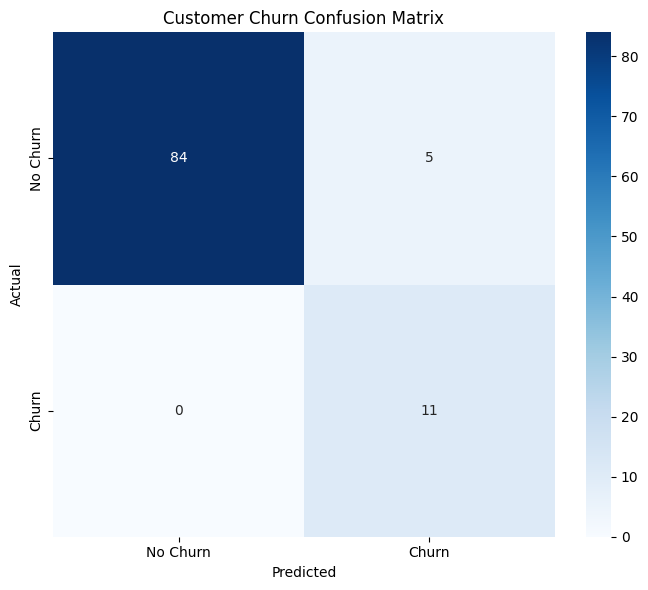

In [267]:
# ============================================================
# CELL 56: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    "Customer Churn Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/confusion_matrix.png",
    dpi=300
)

plt.show()

ROC-AUC
ROC-AUC Score: 0.9990


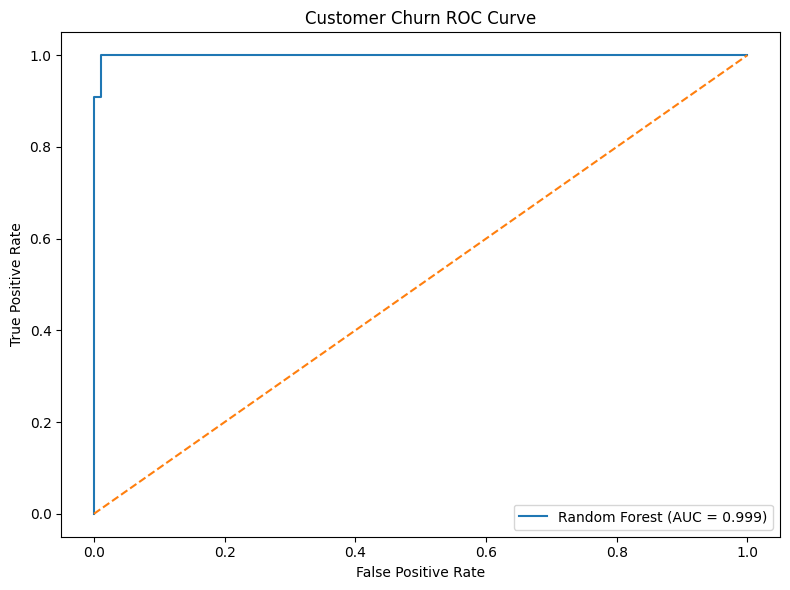

In [268]:
# ============================================================
# CELL 57: ROC-AUC EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

print("=" * 70)
print("ROC-AUC")
print("=" * 70)

print(
    f"ROC-AUC Score: {roc_auc:.4f}"
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Customer Churn ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/charts/roc_curve.png",
    dpi=300
)

plt.show()

In [269]:
# ============================================================
# CELL 58: PERFORMANCE TABLE
# ============================================================

model_performance = pd.DataFrame({
    "Model": [
        "Random Forest Classifier"
    ],
    "Accuracy": [
        accuracy
    ],
    "Precision": [
        precision
    ],
    "Recall": [
        recall
    ],
    "F1_Score": [
        f1
    ],
    "ROC_AUC": [
        roc_auc
    ]
})

print("=" * 70)
print("MODEL PERFORMANCE TABLE")
print("=" * 70)

display(
    model_performance.round(4)
)

MODEL PERFORMANCE TABLE


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest Classifier,0.95,0.6875,1.0,0.8148,0.999


In [270]:
# ============================================================
# CELL 59: SAVE MODEL RESULTS
# ============================================================

model_performance.to_csv(
    "outputs/results/churn_model_performance.csv",
    index=False
)

classification_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Churn_Probability": y_probability
})

classification_results.to_csv(
    "outputs/results/churn_predictions_test.csv",
    index=False
)

print("=" * 70)
print("MODEL RESULTS SAVED")
print("=" * 70)

print(
    "✅ churn_model_performance.csv"
)

print(
    "✅ churn_predictions_test.csv"
)

MODEL RESULTS SAVED
✅ churn_model_performance.csv
✅ churn_predictions_test.csv


ACTUAL VS PREDICTED CHURN


Predicted,0,1
Actual,,
0,84,5
1,0,11


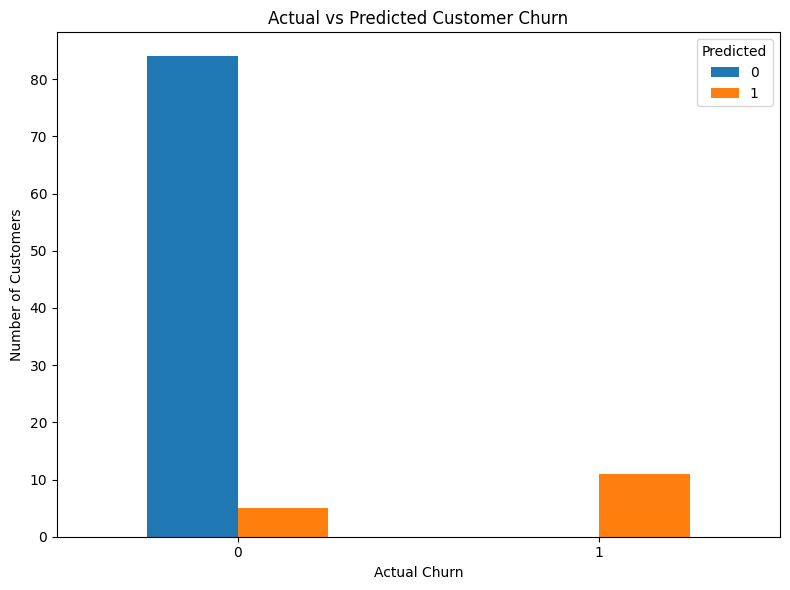

In [271]:
# ============================================================
# CELL 60: ACTUAL VS PREDICTED CHURN
# ============================================================

prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_counts = pd.crosstab(
    prediction_comparison["Actual"],
    prediction_comparison["Predicted"]
)

print("=" * 70)
print("ACTUAL VS PREDICTED CHURN")
print("=" * 70)

display(
    prediction_counts
)

prediction_counts.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title(
    "Actual vs Predicted Customer Churn"
)

plt.xlabel(
    "Actual Churn"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/actual_vs_predicted_churn.png",
    dpi=300
)

plt.show()

In [272]:
# ============================================================
# CELL 61: FEATURE IMPORTANCE
# ============================================================

rf_model = churn_model.named_steps["model"]

# Get feature names after preprocessing
pipeline_feature_names = (
    churn_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance_values = (
    rf_model.feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": pipeline_feature_names,
    "Importance": feature_importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance_df.head(15).round(4)
)

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,numeric__Tenure,0.1698
1,categorical__Tenure_Group_New,0.1677
2,numeric__Customer_Lifetime_Value,0.1307
3,numeric__Charge_Per_Tenure_Month,0.1260
4,numeric__Total_Charges_Per_Month,0.1045
5,categorical__Tenure_Group_Loyal,0.0449
6,categorical__Tenure_Group_Established,0.0428
7,categorical__Tenure_Group_Developing,0.0264
8,categorical__Contract_Month-to-month,0.0247
9,categorical__Contract_One year,0.0218


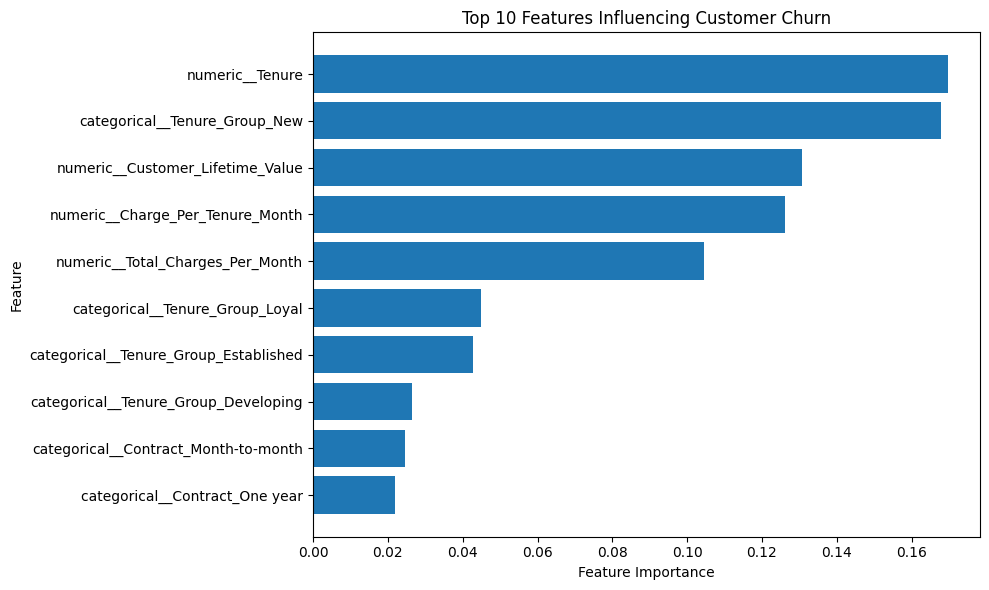

In [273]:
# ============================================================
# CELL 62: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = (
    feature_importance_df
    .head(10)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Features Influencing Customer Churn"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/feature_importance.png",
    dpi=300
)

plt.show()

In [274]:
# ============================================================
# CELL 63: SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance_df.to_csv(
    "outputs/results/feature_importance.csv",
    index=False
)

print(
    "✅ Feature importance saved successfully."
)

print(
    "File:",
    "outputs/results/feature_importance.csv"
)

✅ Feature importance saved successfully.
File: outputs/results/feature_importance.csv


In [275]:
# ============================================================
# CELL 64: CUSTOMER CHURN RISK CLASSIFICATION
# ============================================================

risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values

risk_df["Predicted_Churn"] = y_pred

risk_df["Churn_Probability"] = y_probability

risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[
        -0.01,
        0.30,
        0.60,
        1.01
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

print("=" * 70)
print("CUSTOMER CHURN RISK ANALYSIS")
print("=" * 70)

display(
    risk_df[
        [
            "Actual_Churn",
            "Predicted_Churn",
            "Churn_Probability",
            "Risk_Level"
        ]
    ].head(15)
)

CUSTOMER CHURN RISK ANALYSIS


,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
58,0,0,0.042073,Low Risk
96,0,0,0.094160,Low Risk
350,0,0,0.022763,Low Risk
335,0,0,0.134369,Low Risk
289,0,0,0.031979,Low Risk
380,0,0,0.022690,Low Risk
129,1,1,0.861109,High Risk
339,0,0,0.458542,Medium Risk
472,0,0,0.031977,Low Risk
57,0,0,0.035997,Low Risk


CUSTOMER RISK DISTRIBUTION


Risk_Level
Low Risk       82
Medium Risk     3
High Risk      15
Name: count, dtype: int64

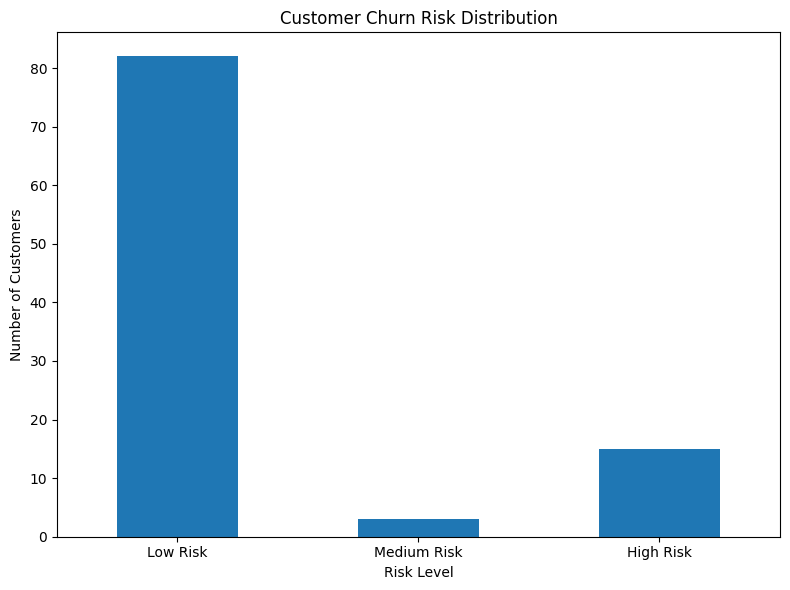

In [276]:
# ============================================================
# CELL 65: RISK DISTRIBUTION
# ============================================================

risk_distribution = (
    risk_df["Risk_Level"]
    .value_counts()
    .reindex(
        [
            "Low Risk",
            "Medium Risk",
            "High Risk"
        ],
        fill_value=0
    )
)

print("=" * 70)
print("CUSTOMER RISK DISTRIBUTION")
print("=" * 70)

display(
    risk_distribution
)

plt.figure(
    figsize=(8, 6)
)

risk_distribution.plot(
    kind="bar"
)

plt.title(
    "Customer Churn Risk Distribution"
)

plt.xlabel(
    "Risk Level"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/churn_risk_distribution.png",
    dpi=300
)

plt.show()

In [277]:
# ============================================================
# CELL 66: HIGH-RISK CUSTOMER ANALYSIS
# ============================================================

high_risk_customers = risk_df[
    risk_df["Risk_Level"] == "High Risk"
].copy()

print("=" * 70)
print("HIGH-RISK CUSTOMER ANALYSIS")
print("=" * 70)

print(
    "High-risk customers:",
    len(high_risk_customers)
)

print(
    "High-risk percentage:",
    round(
        len(high_risk_customers)
        / len(risk_df)
        * 100,
        2
    ),
    "%"
)

display(
    high_risk_customers.head(10)
)

HIGH-RISK CUSTOMER ANALYSIS
High-risk customers: 15
High-risk percentage: 15.0 %


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Customer_Lifetime_Value,Average_Monthly_Value,Tenure_Group,Charge_Per_Tenure_Month,Total_Charges_Per_Month,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
129,C00130,8,174,3979,Two year,Credit Card,Yes,0,1392,174,New,21.750000,497.375000,1,1,0.861109,High Risk
294,C00295,6,59,6657,Two year,Credit Card,No,0,354,59,New,9.833333,1109.500000,0,1,0.705360,High Risk
216,C00217,10,152,5250,Month-to-month,Credit Card,Yes,1,1520,152,New,15.200000,525.000000,1,1,0.931895,High Risk
198,C00199,3,63,1535,Two year,Electronic Check,No,0,189,63,New,21.000000,511.666667,0,1,0.732658,High Risk
18,C00019,7,156,5389,One year,Bank Transfer,Yes,0,1092,156,New,22.285714,769.857143,1,1,0.775786,High Risk
171,C00172,10,115,3717,One year,Electronic Check,Yes,0,1150,115,New,11.500000,371.700000,1,1,0.787054,High Risk
479,C00480,11,160,4666,Two year,Credit Card,No,0,1760,160,New,14.545455,424.181818,1,1,0.802923,High Risk
215,C00216,8,102,2161,One year,Bank Transfer,Yes,1,816,102,New,12.750000,270.125000,0,1,0.615126,High Risk
131,C00132,3,79,891,Month-to-month,Credit Card,No,1,237,79,New,26.333333,297.000000,1,1,0.814158,High Risk
487,C00488,9,72,2417,Month-to-month,Electronic Check,Yes,1,648,72,New,8.000000,268.555556,1,1,0.711806,High Risk


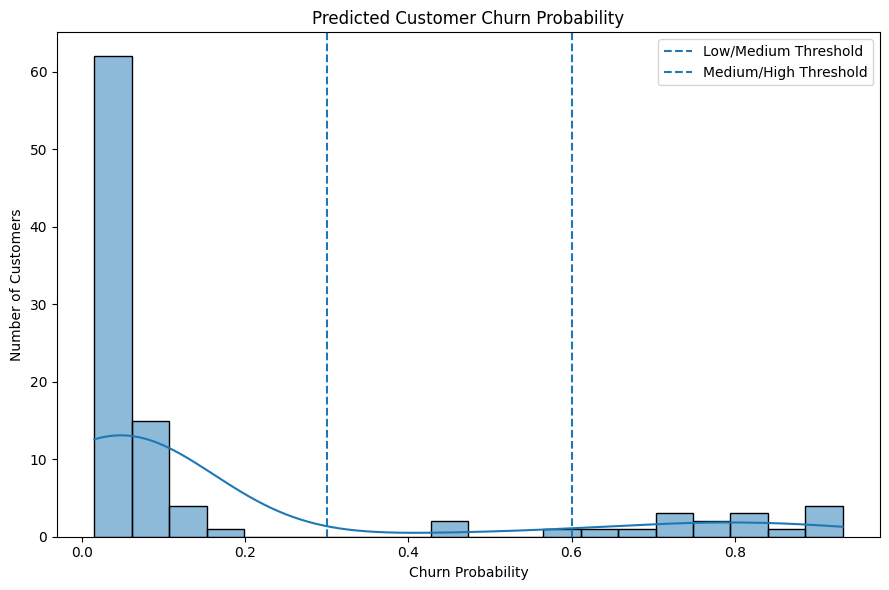

In [278]:
# ============================================================
# CELL 67: CHURN PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

sns.histplot(
    risk_df["Churn_Probability"],
    bins=20,
    kde=True
)

plt.axvline(
    0.30,
    linestyle="--",
    label="Low/Medium Threshold"
)

plt.axvline(
    0.60,
    linestyle="--",
    label="Medium/High Threshold"
)

plt.title(
    "Predicted Customer Churn Probability"
)

plt.xlabel(
    "Churn Probability"
)

plt.ylabel(
    "Number of Customers"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/charts/churn_probability_distribution.png",
    dpi=300
)

plt.show()

In [279]:
# ============================================================
# CELL 68: BUSINESS INSIGHTS
# ============================================================

top_feature = (
    feature_importance_df.iloc[0]["Feature"]
)

top_feature_importance = (
    feature_importance_df.iloc[0]["Importance"]
)

high_risk_percentage = (
    len(high_risk_customers)
    / len(risk_df)
    * 100
)

business_insights = [
    f"1. The trained Random Forest model achieved "
    f"an accuracy of {accuracy:.2%}.",

    f"2. The model achieved an F1 score of "
    f"{f1:.4f}.",

    f"3. The ROC-AUC score was "
    f"{roc_auc:.4f}.",

    f"4. The most important model feature was "
    f"{top_feature}, with importance "
    f"{top_feature_importance:.4f}.",

    f"5. {len(high_risk_customers)} customers "
    f"({high_risk_percentage:.2f}%) in the test "
    f"dataset were classified as high churn risk.",

    "6. Churn probability can be used to prioritize "
    "customers for retention campaigns.",

    "7. Feature engineering and preprocessing "
    "provide a structured dataset suitable for "
    "machine learning."
]

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

for insight in business_insights:
    print(insight)

BUSINESS INSIGHTS
1. The trained Random Forest model achieved an accuracy of 95.00%.
2. The model achieved an F1 score of 0.8148.
3. The ROC-AUC score was 0.9990.
4. The most important model feature was numeric__Tenure, with importance 0.1698.
5. 15 customers (15.00%) in the test dataset were classified as high churn risk.
6. Churn probability can be used to prioritize customers for retention campaigns.
7. Feature engineering and preprocessing provide a structured dataset suitable for machine learning.


In [280]:
# ============================================================
# CELL 69: SAVE BUSINESS ANALYSIS
# ============================================================

with open(
    "outputs/results/business_insights.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "WEEK 10 CUSTOMER CHURN - BUSINESS INSIGHTS\n"
    )

    file.write("=" * 70 + "\n\n")

    for insight in business_insights:
        file.write(
            insight + "\n"
        )

risk_df.to_csv(
    "outputs/results/customer_churn_risk_predictions.csv",
    index=True
)

high_risk_customers.to_csv(
    "outputs/results/high_risk_customers.csv",
    index=True
)

print("=" * 70)
print("BUSINESS ANALYSIS OUTPUTS SAVED")
print("=" * 70)

print(
    "✅ business_insights.txt"
)

print(
    "✅ customer_churn_risk_predictions.csv"
)

print(
    "✅ high_risk_customers.csv"
)

BUSINESS ANALYSIS OUTPUTS SAVED
✅ business_insights.txt
✅ customer_churn_risk_predictions.csv
✅ high_risk_customers.csv


In [281]:
# ============================================================
# CELL 70: ANALYSIS VERIFICATION
# ============================================================

print("=" * 70)
print("WEEK 10 ANALYSIS VERIFICATION")
print("=" * 70)

required_outputs = [
    "outputs/results/feature_importance.csv",
    "outputs/results/business_insights.txt",
    "outputs/results/customer_churn_risk_predictions.csv",
    "outputs/results/high_risk_customers.csv",
    "outputs/charts/feature_importance.png",
    "outputs/charts/churn_risk_distribution.png",
    "outputs/charts/churn_probability_distribution.png",
    "outputs/charts/confusion_matrix.png",
    "outputs/charts/roc_curve.png"
]

missing_outputs = []

for file_path in required_outputs:

    if os.path.exists(file_path):
        print(f"✅ {file_path}")
    else:
        print(f"❌ MISSING: {file_path}")
        missing_outputs.append(file_path)

print("\n" + "=" * 70)

if len(missing_outputs) == 0:

    print(
        "🎉 CELLS 61–70 COMPLETED SUCCESSFULLY!"
    )

else:

    print(
        f"⚠️ {len(missing_outputs)} output(s) missing."
    )

print("=" * 70)

WEEK 10 ANALYSIS VERIFICATION
✅ outputs/results/feature_importance.csv
✅ outputs/results/business_insights.txt
✅ outputs/results/customer_churn_risk_predictions.csv
✅ outputs/results/high_risk_customers.csv
✅ outputs/charts/feature_importance.png
✅ outputs/charts/churn_risk_distribution.png
✅ outputs/charts/churn_probability_distribution.png
✅ outputs/charts/confusion_matrix.png
✅ outputs/charts/roc_curve.png

🎉 CELLS 61–70 COMPLETED SUCCESSFULLY!
